<a href="https://colab.research.google.com/github/mc4830913-max/python/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the e-commerce product dataset from `/content/data.csv (1).zip` by loading it, cleaning null values and unnecessary columns, engineering features like 'product_id', 'estimated_revenue', and 'popularity_score', and removing duplicate rows. Then, perform detailed product, rating, price, discount, popular product, and size availability analyses, visualizing key findings with appropriate charts. Finally, generate key insights and a comprehensive summary of the data processing and analysis.

## Load Libraries and Dataset

### Subtask:
Import necessary libraries (pandas, numpy, matplotlib, seaborn). Unzip the provided file `/content/data.csv (1).zip` and load the contained CSV into a pandas DataFrame. Then, display the dataset's shape, column names, the first 5 rows, and basic information using `.info()` and `.describe()`.


**Reasoning**:
The subtask requires importing libraries, unzipping a file, loading the CSV into a DataFrame, and then displaying various properties of the DataFrame. I will perform all these actions in a single code block.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

print("Libraries imported successfully.")

zip_file_path = '/content/data.csv (1).zip'
extract_dir = '/content/'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File '{zip_file_path}' unzipped to '{extract_dir}'.")

# Assuming the CSV inside is named 'data.csv' or 'data.csv (1).csv'
# Let's list files to be sure
extracted_files = os.listdir(extract_dir)
csv_file_name = None
for f in extracted_files:
    if f.endswith('.csv'):
        csv_file_name = f
        break

if csv_file_name:
    df = pd.read_csv(os.path.join(extract_dir, csv_file_name))
    print(f"CSV file '{csv_file_name}' loaded into DataFrame.")

    # Display shape
    print("\nDataFrame Shape:", df.shape)

    # Display column names
    print("\nDataFrame Columns:", df.columns.tolist())

    # Display first 5 rows
    print("\nFirst 5 Rows of DataFrame:")
    print(df.head())

    # Display info
    print("\nDataFrame Info:")
    df.info()

    # Display descriptive statistics
    print("\nDescriptive Statistics:")
    print(df.describe())
else:
    print("No CSV file found after extraction.")

Libraries imported successfully.
File '/content/data.csv (1).zip' unzipped to '/content/'.
CSV file 'data.csv' loaded into DataFrame.

DataFrame Shape: (168029, 13)

DataFrame Columns: ['product_name', 'brand_name', 'rating', 'rating_count', 'marked_price', 'discounted_price', 'sizes', 'product_link', 'img_link', 'product_tag', 'brand_tag', 'discount_amount', 'discount_percent']

First 5 Rows of DataFrame:
                     product_name      brand_name  rating  rating_count  \
0   Croc Textured Two Fold Wallet     Lino Perros     0.0             0   
1             Men Striped Sliders  Mast & Harbour     4.0            76   
2            Printed A-line Kurta            Biba     4.3            66   
3    Girls Floral Printed T-shirt        Anthrilo     0.0             0   
4  Women Printed Kurta with Skirt    FASHION DWAR     0.0             0   

   marked_price  discounted_price                      sizes  \
0          1295               828                    Onesize   
1          

## Data Cleaning - Null Values and Ratings

### Subtask:
Identify and handle missing values and remove products with zero ratings.


**Reasoning**:
First, I'll check for missing values across all columns to understand the extent of null data. Then, I'll drop rows containing nulls in critical columns and filter out products with zero ratings as per the instructions. Finally, I'll display the DataFrame's new shape to reflect these changes.



In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows where any of the specified columns have null values
initial_rows = df.shape[0]
df.dropna(subset=['product_name', 'brand_name', 'rating', 'rating_count', 'marked_price', 'discounted_price'], inplace=True)
print(f"\n{initial_rows - df.shape[0]} rows dropped due to null values in specified columns.")

# Remove rows where 'rating' is 0.0
initial_rows = df.shape[0]
df = df[df['rating'] != 0.0]
print(f"{initial_rows - df.shape[0]} rows dropped due to zero ratings.")

print("\nDataFrame shape after cleaning:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
product_name        0
brand_name          0
rating              0
rating_count        0
marked_price        0
discounted_price    0
sizes               0
product_link        0
img_link            0
product_tag         0
brand_tag           0
discount_amount     0
discount_percent    0
dtype: int64

0 rows dropped due to null values in specified columns.
76680 rows dropped due to zero ratings.

DataFrame shape after cleaning: (91349, 13)
Missing values after cleaning:
product_name        0
brand_name          0
rating              0
rating_count        0
marked_price        0
discounted_price    0
sizes               0
product_link        0
img_link            0
product_tag         0
brand_tag           0
discount_amount     0
discount_percent    0
dtype: int64


## Data Cleaning - Unnecessary Columns

### Subtask:
Explain the rationale for removing columns that are not useful for analysis and then drop the 'product_link' and 'brand_tag' columns. Note that 'img_link' will be dropped in a subsequent step after 'product_id' is extracted from it.


**Reasoning**:
Now that the rationale for dropping columns has been provided, I will drop the 'product_link' and 'brand_tag' columns from the DataFrame `df` and then display the updated column list to confirm the changes.



In [ ]:
print("Columns before dropping:\n", df.columns.tolist())

# Drop 'product_link' and 'brand_tag' columns
df.drop(columns=['product_link', 'brand_tag'], inplace=True)

print("\nColumns after dropping 'product_link' and 'brand_tag':\n", df.columns.tolist())

Columns before dropping:
 ['product_name', 'brand_name', 'rating', 'rating_count', 'marked_price', 'discounted_price', 'sizes', 'product_link', 'img_link', 'product_tag', 'brand_tag', 'discount_amount', 'discount_percent']

Columns after dropping 'product_link' and 'brand_tag':
 ['product_name', 'brand_name', 'rating', 'rating_count', 'marked_price', 'discounted_price', 'sizes', 'img_link', 'product_tag', 'discount_amount', 'discount_percent']


## Feature Engineering - Product ID and Revenue

### Subtask:
Extract the unique product ID from the 'img_link' column, create a new column 'product_id', insert it at the beginning of the DataFrame, and then create a new column named 'estimated_revenue' by calculating `rating_count * marked_price`. Finally, drop the 'img_link' column.


**Reasoning**:
I will extract the product ID from the 'img_link' column, create a new 'product_id' column, reposition it, calculate 'estimated_revenue', drop 'img_link', and then display the head and info of the modified DataFrame to verify the changes.



In [ ]:
import re
def extract_product_id(img_link):
   match = re.search(r'/images/(\d+)/', img_link)
   if match:
        return match.group(1)
   return None

df['product_id'] = df['img_link'].apply(extract_product_id)

current_columns = df.columns.tolist()
if 'product_id' in current_columns:
    current_columns.remove('product_id')
    new_column_order = ['product_id'] + current_columns
    df = df[new_column_order]

# 4. Create 'estimated_revenue' column
df['estimated_revenue'] = df['rating_count'] * df['marked_price']

# 5. Drop the 'img_link' column
df.drop(columns=['img_link'], inplace=True)

print("DataFrame after feature engineering:")
# 6. Display the first 5 rows and info
print(df.head())
print("\nDataFrame Info after feature engineering:")
df.info()

DataFrame after feature engineering:
  product_id              product_name      brand_name  rating  rating_count  \
1   12548958       Men Striped Sliders  Mast & Harbour     4.0            76   
2   13446092      Printed A-line Kurta            Biba     4.3            66   
5    7726509  Floral Cotton Maxi Dress         Vishudh     4.1           800   
6   14424536           Fitted Crop Top   Tokyo Talkies     4.4           210   
7       None    Men Mesh Running Shoes         Woakers     3.4           591   

   marked_price  discounted_price                      sizes   product_tag  \
1          1299               584  UK6,UK7,UK8,UK9,UK10,UK11    flip-flops   
2          1999              1599           S,M,L,XL,XXL,3XL        kurtas   
5          4349              1826               S,M,L,XL,XXL       dresses   
6           499               249                   S,M,L,XL          tops   
7          3125               687       UK6,UK7,UK8,UK9,UK10  sports-shoes   

   discount_a

**Reasoning**:
The previous code produced a `SettingWithCopyWarning`. This is often resolved by explicitly creating a copy of the DataFrame after filtering operations, ensuring subsequent assignments modify the main DataFrame rather than a view. I will add `.copy()` to the line where `df` was filtered to prevent this warning.



## Feature Engineering - Remove Duplicates

### Subtask:
Identify and remove duplicate rows from the dataset to ensure data integrity.


**Reasoning**:
To ensure data integrity, I will identify and remove all duplicate rows from the DataFrame `df` using the `drop_duplicates` method with `keep=False` to eliminate all occurrences of duplicate entries. I will then display the number of duplicates found and the new shape of the DataFrame.



In [ ]:
initial_rows = df.shape[0]

# Identify and count duplicate rows (marking all instances as True)
duplicate_rows = df[df.duplicated(keep=False)]
num_duplicates = duplicate_rows.shape[0]

# Remove all duplicate rows (keeping no instances)
df_cleaned = df.drop_duplicates(keep=False)

# Calculate rows removed (total rows before - rows after dropping all duplicates)
rows_removed = initial_rows - df_cleaned.shape[0]

df = df_cleaned.copy() # Update the original DataFrame

print(f"Number of duplicate rows identified and removed (all instances): {rows_removed}")
print(f"DataFrame shape after removing duplicate rows: {df.shape}")

Number of duplicate rows identified and removed (all instances): 17892
DataFrame shape after removing duplicate rows: (73457, 12)


## Final Clean Dataset and Save

### Subtask:
Display the final shape of the cleaned dataset and show a preview of its first few rows. Save the cleaned dataset as `cleaned_ecommerce_products.csv`.


**Reasoning**:
I will display the final shape and the first few rows of the cleaned DataFrame, and then save it to a CSV file as requested by the subtask.



In [ ]:
print("Final DataFrame Shape:", df.shape)
print("\nFirst 5 Rows of Final DataFrame:")
print(df.head(10))

# Save the cleaned DataFrame to a CSV file
output_filename = 'cleaned_ecommerce_products.csv'
df.to_csv(output_filename, index=False)
print(f"\nCleaned DataFrame saved to '{output_filename}'.")

Final DataFrame Shape: (73457, 12)

First 5 Rows of Final DataFrame:
   product_id                      product_name      brand_name  rating  \
1    12548958               Men Striped Sliders  Mast & Harbour     4.0   
2    13446092              Printed A-line Kurta            Biba     4.3   
5     7726509          Floral Cotton Maxi Dress         Vishudh     4.1   
6    14424536                   Fitted Crop Top   Tokyo Talkies     4.4   
7        None            Men Mesh Running Shoes         Woakers     3.4   
8    15654428              Men Checked Pullover        Roadster     4.3   
9    16929940           Girls Cotton Jersey Top             H&M     4.2   
10   18212980                  Cotton Twill Cap             H&M     4.2   
11   16107014     Women Geometric Printed Kurta         Vishudh     4.3   
12   18083510  Women  Solid Cotton Lounge Pants   Mystere Paris     4.2   

    rating_count  marked_price  discounted_price                       sizes  \
1             76         

## Product Analysis

### Subtask:
Answer questions about total products, most frequent product categories, and brands with the highest product counts. Visualize the top 10 brands by product count using a bar chart and the product category distribution using a pie chart.


**Reasoning**:
I need to perform product analysis by calculating total products, identifying frequent product categories and brands, and visualizing the top brands and product categories using bar and pie charts, respectively. This will be done in a single code block for efficiency.



Total number of unique products: 73457

Most frequent product categories (Top 10):
 product_tag
tshirts         7321
shirts          4733
dresses         4603
kurta-sets      3872
tops            3707
kurtas          3465
jeans           3346
handbags        2539
casual-shoes    2382
trousers        2330
Name: count, dtype: int64

Brands with the highest number of products (Top 10):
 brand_name
Roadster                 3468
Mast & Harbour           1770
DressBerry               1474
HIGHLANDER               1312
HRX by Hrithik Roshan    1261
Anouk                    1221
Tokyo Talkies            1167
HERE&NOW                 1097
H&M                       942
Puma                      938
Name: count, dtype: int64


/tmp/ipykernel_1694/3140196846.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_product_counts.head(10).index, y=brand_product_counts.head(10).values, palette='viridis')


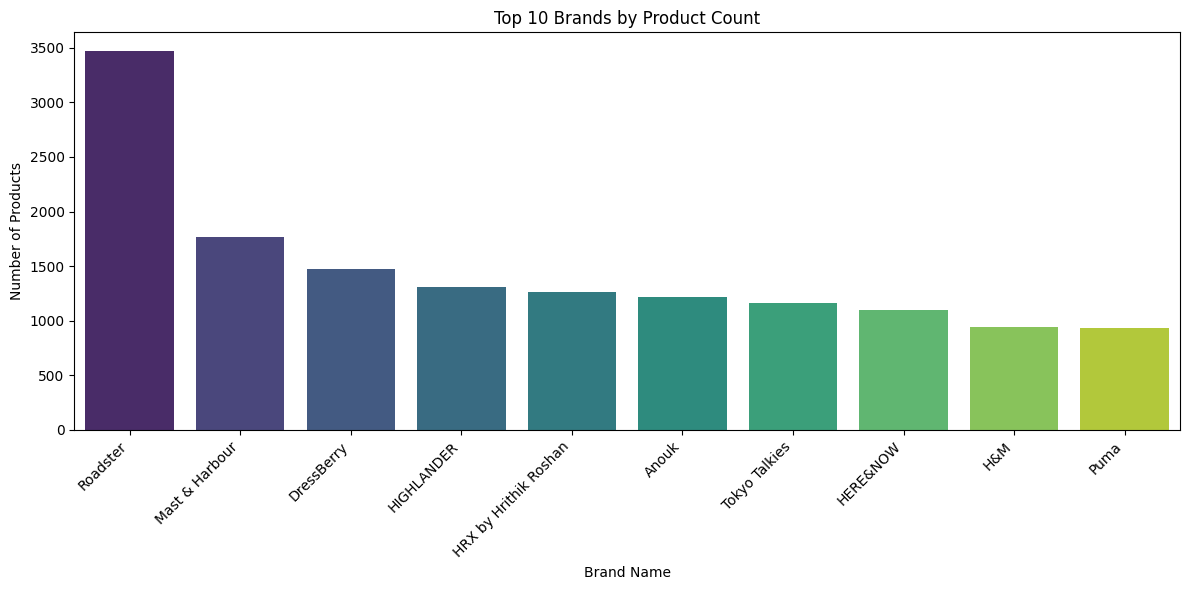

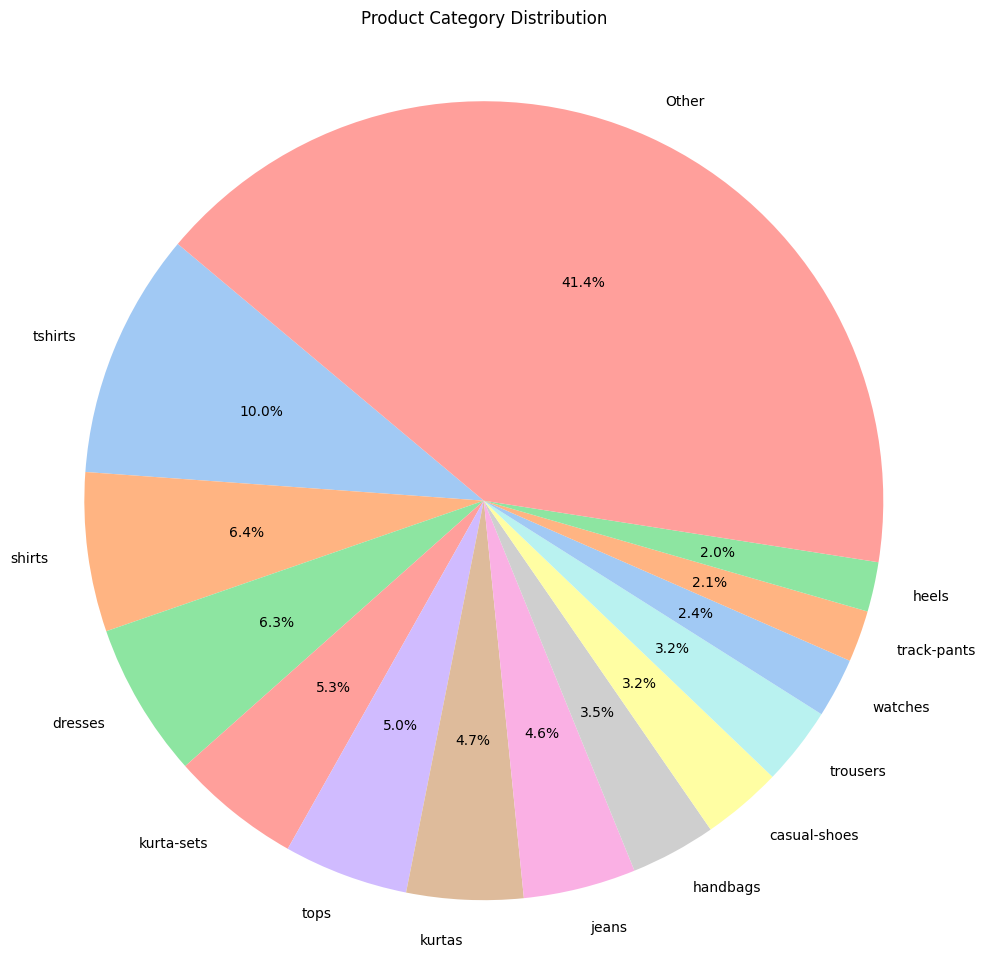

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the total number of unique products
total_products = df.shape[0]
print(f"Total number of unique products: {total_products}")

# 2. Find the most frequent product categories
product_tag_counts = df['product_tag'].value_counts()
print("\nMost frequent product categories (Top 10):\n", product_tag_counts.head(10))

# 3. Find the brands that offer the highest number of products
brand_product_counts = df['brand_name'].value_counts()
print("\nBrands with the highest number of products (Top 10):\n", brand_product_counts.head(10))

# 4. Create a bar chart showing the top 10 brands by their product count
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_product_counts.head(10).index, y=brand_product_counts.head(10).values, palette='viridis')
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Brand Name')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Create a pie chart showing the distribution of product categories
# For better readability, let's group smaller categories into 'Other'
threshold = product_tag_counts.sum() * 0.02 # Categories less than 2% will be grouped
other_categories = product_tag_counts[product_tag_counts < threshold]
main_categories = product_tag_counts[product_tag_counts >= threshold]

# If there are 'other' categories, add them as a single slice
if not other_categories.empty:
    main_categories['Other'] = other_categories.sum()

plt.figure(figsize=(10, 10))
plt.pie(main_categories, labels=main_categories.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Product Category Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` because `palette` was used without `hue` in `sns.barplot`. I will update the `sns.barplot` call to explicitly set `x` as `hue` and `legend=False` to align with the recommended usage and suppress the warning.



## Rating Analysis

### Subtask:
Answer questions about average rating, products with the highest number of ratings, and brands with the highest average ratings. Visualize the relationship between 'rating' and 'rating_count' with a scatter plot, and display the average rating by brand using a bar chart.


**Reasoning**:
I need to calculate the overall average rating, identify top products by rating count, determine top brands by average rating, and then visualize the relationship between rating and rating count with a scatter plot, and display the average rating by brand using a bar chart, as requested by the subtask.



Overall average rating of all products: 4.17

Top 10 products with the highest rating count:
                              product_name             brand_name  rating  \
33432            Unisex Skin Care Gift Set               Biotique     4.4   
59424               Kajal & Bold Liner Set             Maybelline     4.5   
104447  Printed Cotton Pure Cotton T-shirt  HRX by Hrithik Roshan     4.3   
108846                  Skin Care Gift Set               Biotique     4.4   
160063        Set of Foundation & Eyeliner             Maybelline     4.4   
83734            Set of Eyeliner & Mascara             Maybelline     4.5   
55661       Sustainable Skin Care Gift Set               Biotique     4.4   
164299              Set Of Toner & Eye Gel               Biotique     4.4   
142487              Colossal Kajal - Black             Maybelline     4.4   
158458            Set Of Toner & Face Wash               Biotique     4.4   

        rating_count  
33432          55900  
59424        

/tmp/ipykernel_1694/2107464141.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


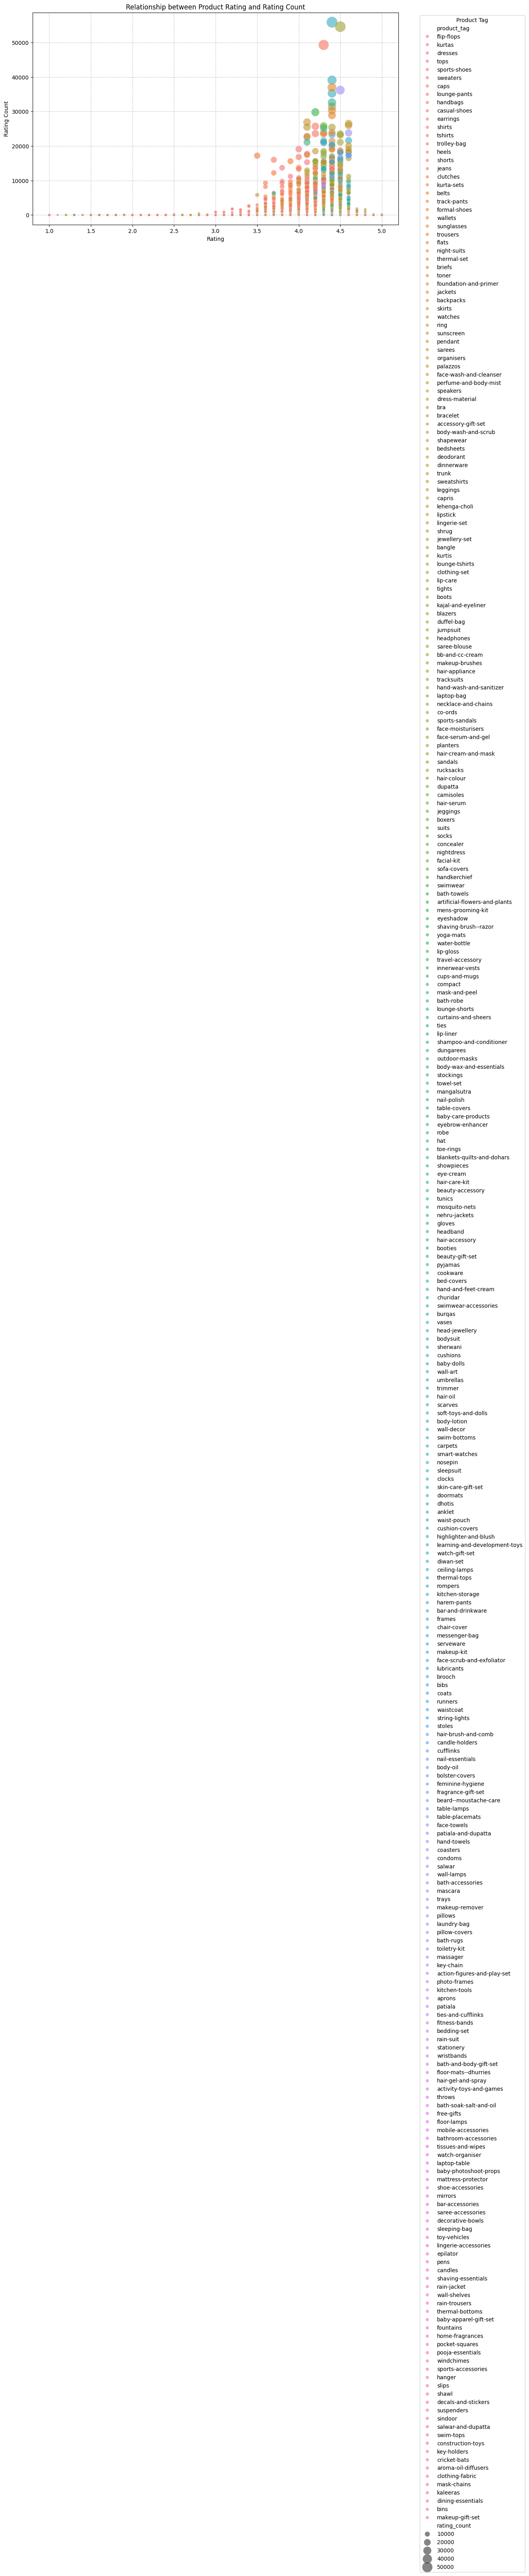

/tmp/ipykernel_1694/2107464141.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_brands_by_avg_rating.index, y=top_10_brands_by_avg_rating.values, palette='coolwarm')


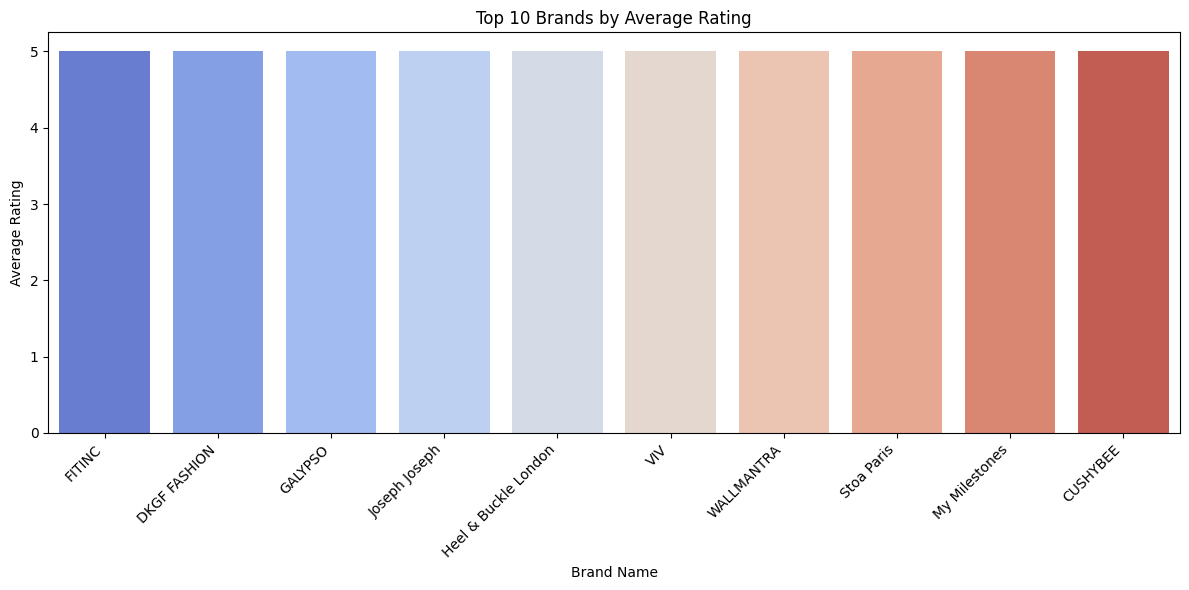

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate and print the overall average rating
overall_average_rating = df['rating'].mean()
print(f"Overall average rating of all products: {overall_average_rating:.2f}")

# 2. Identify and print the top 10 products with the highest 'rating_count'
top_products_by_rating_count = df.sort_values(by='rating_count', ascending=False).head(10)
print("\nTop 10 products with the highest rating count:")
print(top_products_by_rating_count[['product_name', 'brand_name', 'rating', 'rating_count']])

# 3. Calculate the average 'rating' for each 'brand_name' and identify top 10
average_rating_by_brand = df.groupby('brand_name')['rating'].mean().sort_values(ascending=False)
top_10_brands_by_avg_rating = average_rating_by_brand.head(10)
print("\nTop 10 brands with the highest average ratings:")
print(top_10_brands_by_avg_rating)

# 4. Create a scatter plot to visualize the relationship between 'rating' and 'rating_count'
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='rating', y='rating_count', alpha=0.6, hue='product_tag', size='rating_count', sizes=(20, 400), legend='brief')
plt.title('Relationship between Product Rating and Rating Count')
plt.xlabel('Rating')
plt.ylabel('Rating Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Product Tag', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Create a bar chart to display the average rating of the top 10 brands
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_brands_by_avg_rating.index, y=top_10_brands_by_avg_rating.values, palette='coolwarm')
plt.title('Top 10 Brands by Average Rating')
plt.xlabel('Brand Name')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Price Analysis

### Subtask:
Answer questions about average marked price and discounted price, product price distribution, and which brands sell high-priced vs low-priced products. Visualize the price distribution with a histogram and compare 'marked_price' versus 'discounted_price' using a boxplot.


**Reasoning**:
I will calculate the average marked and discounted prices, determine top/bottom brands by marked price, and then generate a histogram for discounted price distribution and a boxplot to compare marked and discounted prices, as specified in the instructions.



Overall average marked price: 2334.53
Overall average discounted price: 1245.08


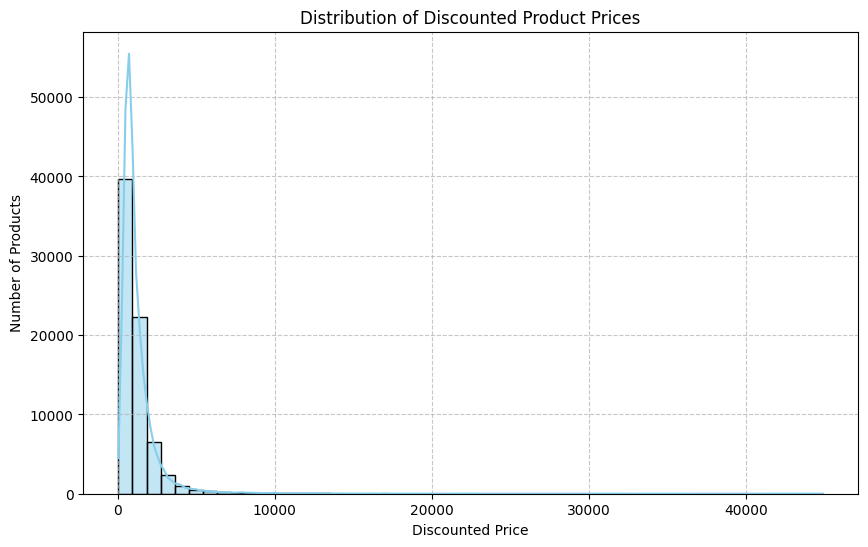


Top 5 brands with the highest average marked price:
brand_name
dyson                       39233.333333
EARNSHAW                    30950.000000
Apple                       26300.000000
Swiss Military by Chrono    24750.000000
TISSOT                      24500.000000
Name: marked_price, dtype: float64

Top 5 brands with the lowest average marked price:
brand_name
BIOAYURVEDA     85.000000
ELLE 18         89.285714
Remove         110.000000
Blue Heaven    123.333333
Miss Claire    149.766667
Name: marked_price, dtype: float64


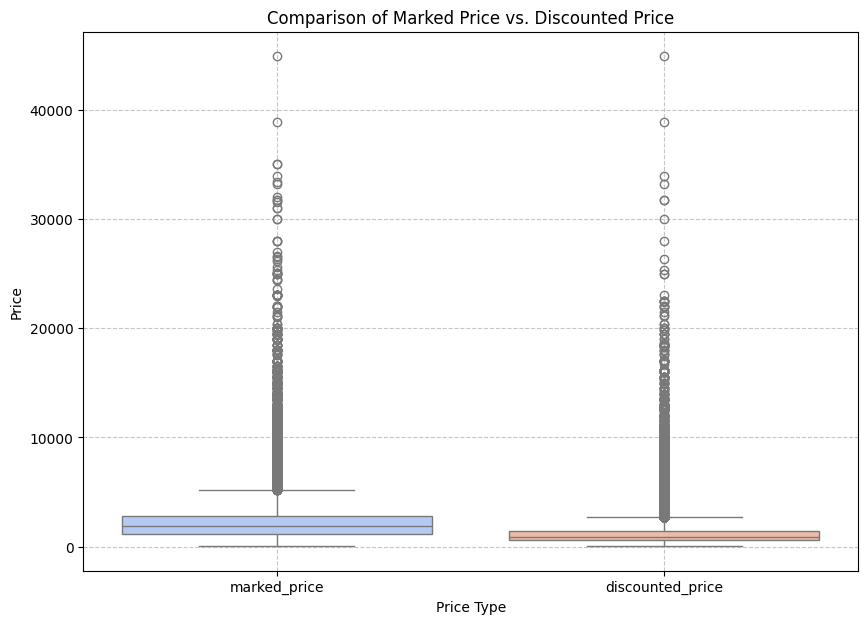

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate and print the overall average 'marked_price' and 'discounted_price'
average_marked_price = df['marked_price'].mean()
average_discounted_price = df['discounted_price'].mean()
print(f"Overall average marked price: {average_marked_price:.2f}")
print(f"Overall average discounted price: {average_discounted_price:.2f}")

# 2. Create a histogram to visualize the distribution of 'discounted_price'
plt.figure(figsize=(10, 6))
sns.histplot(df['discounted_price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Discounted Product Prices')
plt.xlabel('Discounted Price')
plt.ylabel('Number of Products')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Identify the top 5 brands with the highest average 'marked_price'
highest_avg_marked_price_brands = df.groupby('brand_name')['marked_price'].mean().nlargest(5)
print("\nTop 5 brands with the highest average marked price:")
print(highest_avg_marked_price_brands)

# 4. Identify the top 5 brands with the lowest average 'marked_price'
lowest_avg_marked_price_brands = df.groupby('brand_name')['marked_price'].mean().nsmallest(5)
print("\nTop 5 brands with the lowest average marked price:")
print(lowest_avg_marked_price_brands)

# 5. Create a boxplot to compare 'marked_price' and 'discounted_price'
# Melt the DataFrame to long format for easier plotting
price_df_melted = df[['marked_price', 'discounted_price']].melt(var_name='Price Type', value_name='Price')

plt.figure(figsize=(10, 7))
sns.boxplot(data=price_df_melted, x='Price Type', y='Price', hue='Price Type', palette='coolwarm', legend=False) # Fixed FutureWarning
plt.title('Comparison of Marked Price vs. Discounted Price')
plt.xlabel('Price Type')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Discount Analysis

### Subtask:
Calculate discount percentages. Answer the questions: 'Which products offer the highest discounts?', 'What is the average discount percentage across brands?', and 'How are discount percentages distributed across products?'. Visualize the top discounted products with a bar chart and the discount percentage distribution with a histogram. Ensure all plots are clean, professional, and properly labeled with titles and axis labels.


**Reasoning**:
I will perform the discount analysis as per the instructions, including identifying top discounted products, calculating average discount percentages by brand, and generating a bar chart for top products and a histogram for discount percentage distribution.




Top 10 products with the highest discount percentage:
                          product_name brand_name  marked_price  \
107414               Men Walking Shoes    MENGLER          3999   
111725        Floral Block Print Saree    HRITIKA          6099   
151154         Batik Block Print Saree    HRITIKA          6099   
66492      Ethnic Motifs Printed Saree    HRITIKA          6099   
141253               Block Print Saree    HRITIKA          6099   
160945             Chiffon Satin Saree    HRITIKA          7990   
101941                           Saree    HRITIKA          8490   
52555         Floral Block Print Saree    HRITIKA          6099   
41664   Cotton Blend Block Print Saree    HRITIKA          6099   
85411         Floral Block Print Saree    HRITIKA          6099   

        discounted_price  discount_percent  
107414               399                90  
111725               609                90  
151154               609                90  
66492                609   

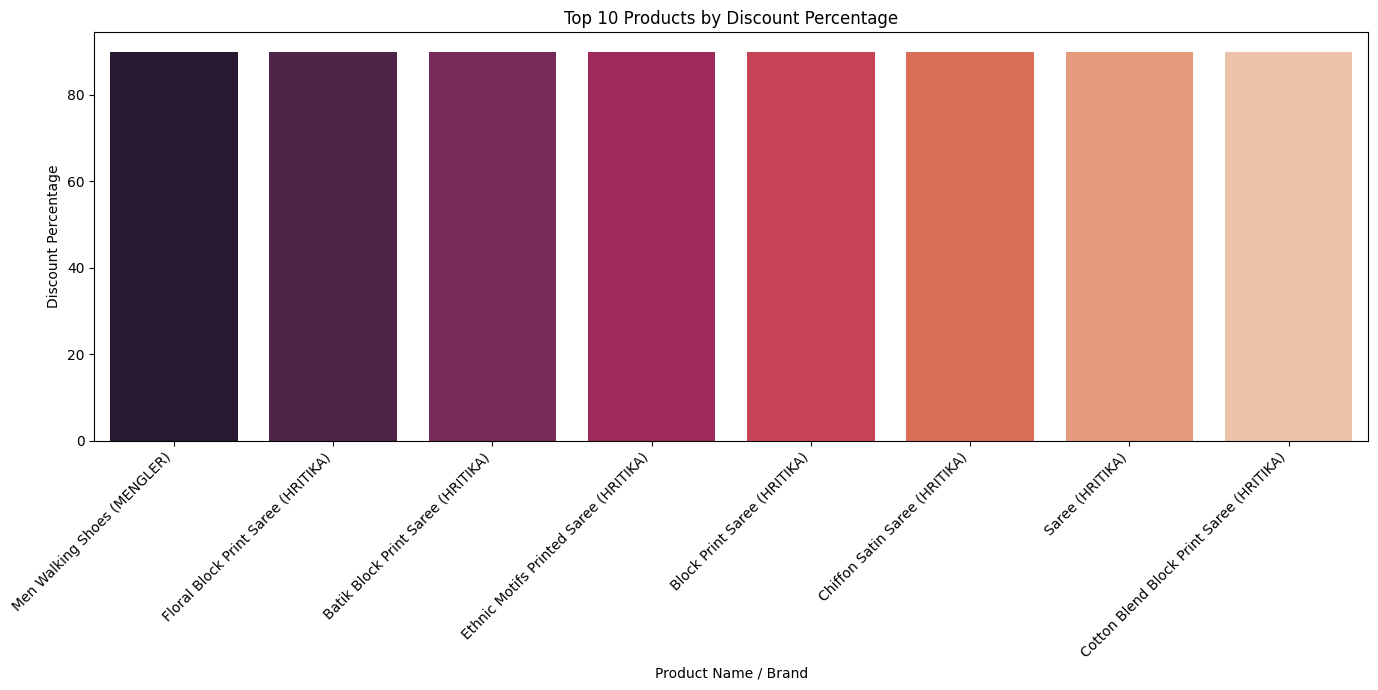

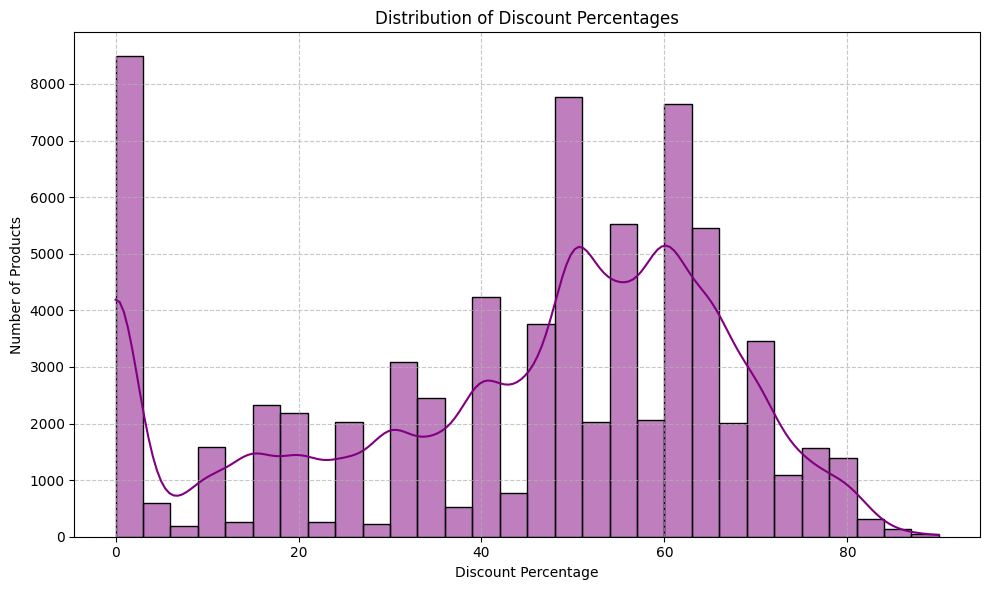

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify and print the top 10 products with the highest 'discount_percent'
#    Display their 'product_name', 'brand_name', 'marked_price', 'discounted_price', and 'discount_percent'.
top_discounted_products = df.sort_values(by='discount_percent', ascending=False).head(10)
print("\nTop 10 products with the highest discount percentage:")
print(top_discounted_products[['product_name', 'brand_name', 'marked_price', 'discounted_price', 'discount_percent']])

# 2. Calculate the average 'discount_percent' for each 'brand_name' and print the top 10 brands
#    with the highest average discount percentage.
average_discount_by_brand = df.groupby('brand_name')['discount_percent'].mean().sort_values(ascending=False)
top_10_brands_by_avg_discount = average_discount_by_brand.head(10)
print("\nTop 10 brands with the highest average discount percentage:")
print(top_10_brands_by_avg_discount)

# 3. Create a bar chart showing the top 10 products with the highest discount percentage.
plt.figure(figsize=(14, 7))
sns.barplot(x=top_discounted_products['product_name'] + ' (' + top_discounted_products['brand_name'] + ')',
            y=top_discounted_products['discount_percent'],
            hue=top_discounted_products['product_name'] + ' (' + top_discounted_products['brand_name'] + ')', # Fixed FutureWarning
            palette='rocket', legend=False)
plt.title('Top 10 Products by Discount Percentage')
plt.xlabel('Product Name / Brand')
plt.ylabel('Discount Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Create a histogram to visualize the distribution of 'discount_percent'.
plt.figure(figsize=(10, 6))
sns.histplot(df['discount_percent'], bins=30, kde=True, color='purple')
plt.title('Distribution of Discount Percentages')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Products')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Popular Product Analysis

### Subtask:
Create a new column called 'popularity_score' using the formula `rating * rating_count`. Answer the questions: 'Which products have the highest popularity score?' and 'Which brands have the most popular products?'. Visualize the top 20 most popular products using a bar chart. Ensure all plots are clean, professional, and properly labeled with titles and axis labels.


**Reasoning**:
I will create the 'popularity_score' column, identify and display the top 10 products and brands by this score, and then visualize the top 20 products with a bar chart, as detailed in the instructions.



Created 'popularity_score' column.

Top 10 products with the highest popularity score:
                              product_name             brand_name  rating  \
33432            Unisex Skin Care Gift Set               Biotique     4.4   
59424               Kajal & Bold Liner Set             Maybelline     4.5   
104447  Printed Cotton Pure Cotton T-shirt  HRX by Hrithik Roshan     4.3   
108846                  Skin Care Gift Set               Biotique     4.4   
83734            Set of Eyeliner & Mascara             Maybelline     4.5   
160063        Set of Foundation & Eyeliner             Maybelline     4.4   
55661       Sustainable Skin Care Gift Set               Biotique     4.4   
164299              Set Of Toner & Eye Gel               Biotique     4.4   
142487              Colossal Kajal - Black             Maybelline     4.4   
158458            Set Of Toner & Face Wash               Biotique     4.4   

        rating_count  popularity_score  
33432          55900    

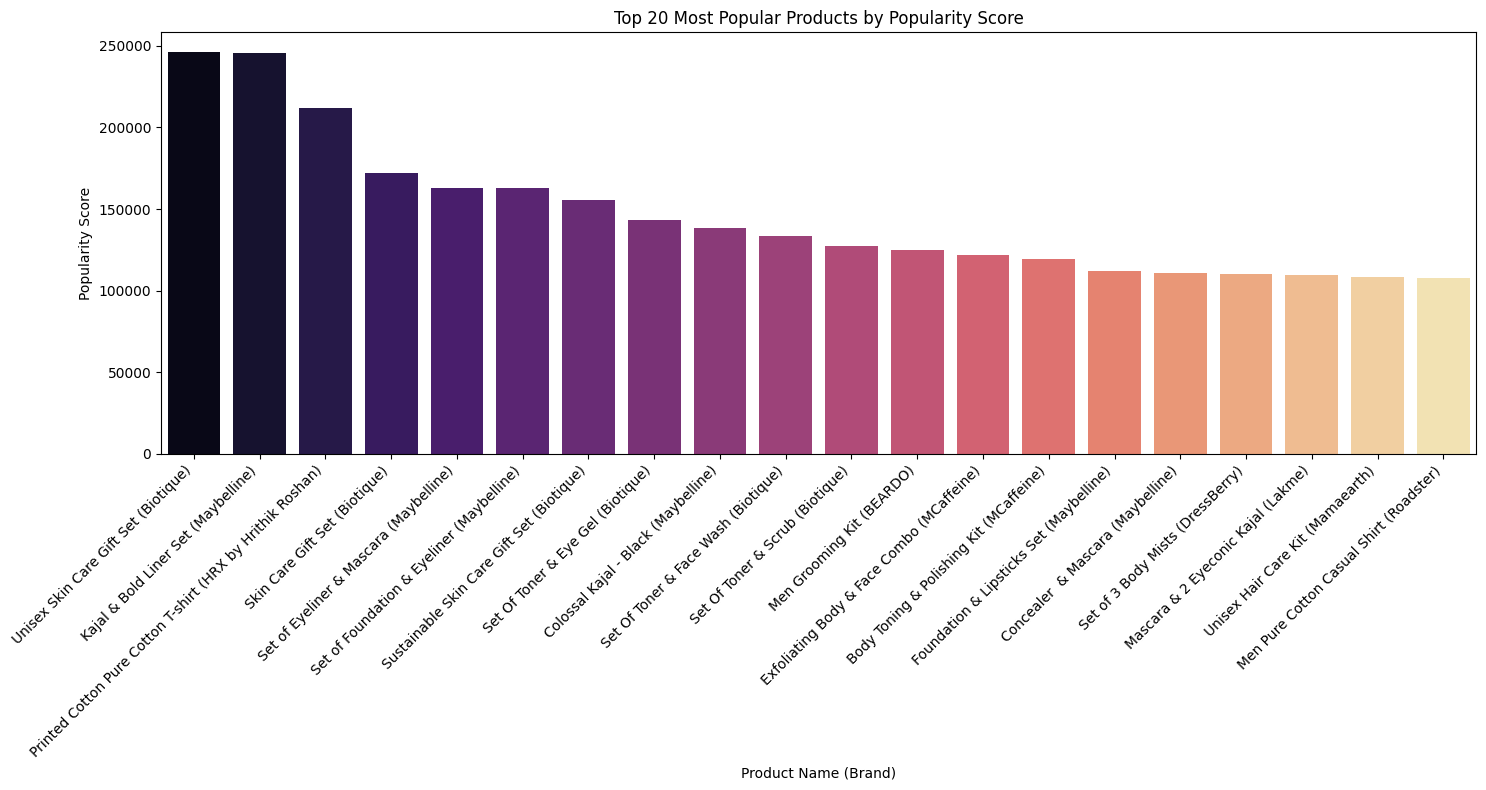

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a new column 'popularity_score'
df['popularity_score'] = df['rating'] * df['rating_count']
print("Created 'popularity_score' column.")

# 2. Identify and print the top 10 products with the highest 'popularity_score'
top_products_by_popularity = df.sort_values(by='popularity_score', ascending=False).head(10)
print("\nTop 10 products with the highest popularity score:")
print(top_products_by_popularity[['product_name', 'brand_name', 'rating', 'rating_count', 'popularity_score']])

# 3. Calculate the sum of 'popularity_score' for each 'brand_name' and identify the top 10 brands
brand_popularity_scores = df.groupby('brand_name')['popularity_score'].sum().sort_values(ascending=False)
top_10_brands_by_popularity = brand_popularity_scores.head(10)
print("\nTop 10 brands with the most popular products (by total popularity score):")
print(top_10_brands_by_popularity)

# 4. Create a bar chart showing the top 20 products with the highest 'popularity_score'
top_20_popular_products = df.sort_values(by='popularity_score', ascending=False).head(20)

plt.figure(figsize=(15, 8))
sns.barplot(x=top_20_popular_products['product_name'] + ' (' + top_20_popular_products['brand_name'] + ')',
            y=top_20_popular_products['popularity_score'],
            hue=top_20_popular_products['product_name'] + ' (' + top_20_popular_products['brand_name'] + ')',
            palette='magma', legend=False)
plt.title('Top 20 Most Popular Products by Popularity Score')
plt.xlabel('Product Name (Brand)')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Size Availability Analysis

### Subtask:
Answer questions about most commonly available sizes and brands with widest range of sizes. Visualize the size frequency distribution with a bar chart.


**Reasoning**:
I will define a function to parse the 'sizes' column, which contains comma-separated values, into a list of individual sizes. This function will then be applied to create a new column named 'individual_sizes' in the DataFrame, which is the first step towards analyzing size availability.



In [ ]:
import pandas as pd

def parse_sizes(sizes_str):
    if isinstance(sizes_str, str):
        return [s.strip() for s in sizes_str.split(',') if s.strip()]
    return []

df['individual_sizes'] = df['sizes'].apply(parse_sizes)

print("DataFrame with 'individual_sizes' column:")
print(df[['sizes', 'individual_sizes']].head())

DataFrame with 'individual_sizes' column:
                       sizes                  individual_sizes
1  UK6,UK7,UK8,UK9,UK10,UK11  [UK6, UK7, UK8, UK9, UK10, UK11]
2           S,M,L,XL,XXL,3XL           [S, M, L, XL, XXL, 3XL]
5               S,M,L,XL,XXL                [S, M, L, XL, XXL]
6                   S,M,L,XL                     [S, M, L, XL]
7       UK6,UK7,UK8,UK9,UK10        [UK6, UK7, UK8, UK9, UK10]


**Reasoning**:
Now that the 'individual_sizes' column has been created, I will expand this column to create a new DataFrame where each size has its own row. This will facilitate counting individual size frequencies and allow for the identification of the most commonly available sizes and brands with the widest range of sizes. Finally, I will visualize the top 10 most common sizes with a bar chart.




Top 10 most commonly available sizes:
individual_sizes
M          30162
L          30155
S          28863
XL         28503
XXL        16497
XS         12101
Onesize    11862
32          7349
34          7284
30          7220
Name: count, dtype: int64

Top 10 brands with the widest range of sizes:
brand_name
H&M                     128
max                      95
Marks & Spencer          74
Domyos By Decathlon      68
Mast & Harbour           67
Quechua By Decathlon     60
Zivame                   59
PARFAIT                  58
Jack & Jones             52
Puma                     52
Name: individual_sizes, dtype: int64


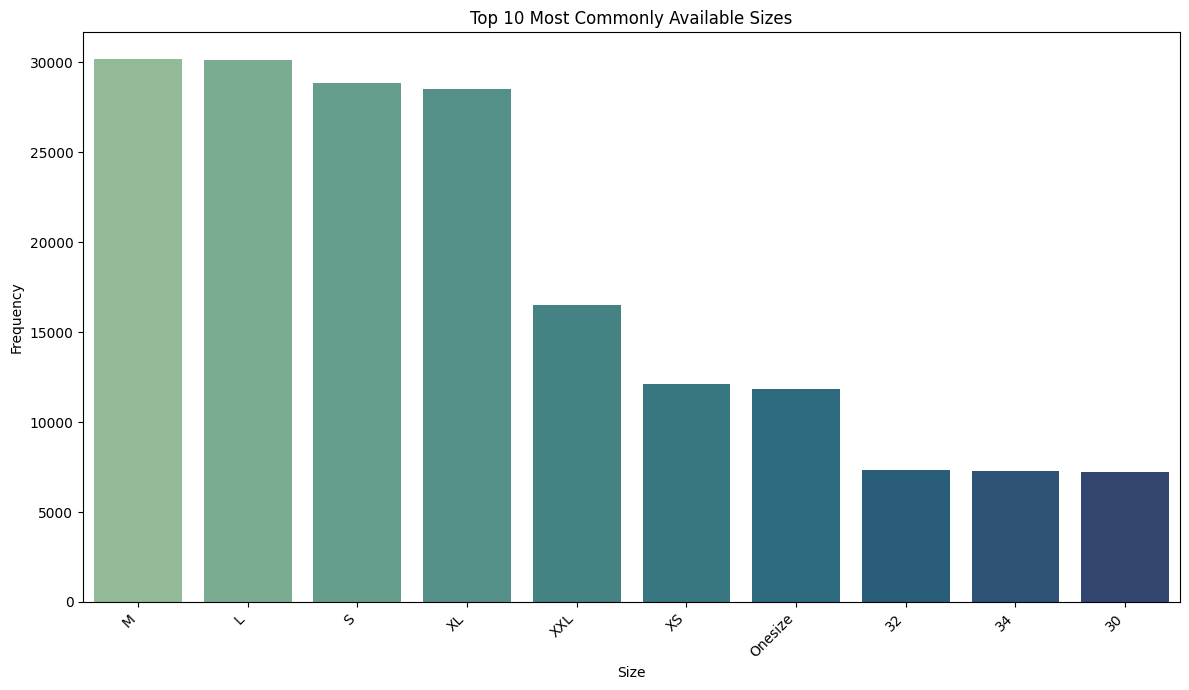

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Expand the 'individual_sizes' column
sizes_expanded = df.explode('individual_sizes')

# 3. Count the frequency of each unique size and print the top 10
size_frequency = sizes_expanded['individual_sizes'].value_counts()
print("\nTop 10 most commonly available sizes:")
print(size_frequency.head(10))

# 4. Calculate the number of unique sizes offered by each brand and print the top 10 brands
# Group by brand_name and then count unique individual_sizes for each brand
brand_unique_sizes = sizes_expanded.groupby('brand_name')['individual_sizes'].nunique().sort_values(ascending=False)
print("\nTop 10 brands with the widest range of sizes:")
print(brand_unique_sizes.head(10))

# 5. Create a bar chart to visualize the frequency distribution of the top 10 most commonly available sizes
plt.figure(figsize=(12, 7))
sns.barplot(x=size_frequency.head(10).index, y=size_frequency.head(10).values, hue=size_frequency.head(10).index, palette='crest', legend=False)
plt.title('Top 10 Most Commonly Available Sizes')
plt.xlabel('Size')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Generate Key Insights

### Subtask:
Automatically generate and display key insights from the analysis, including the brand with the highest number of products, the most common product category, the average product price range, brands offering the largest discounts, and the most popular products based on ratings and reviews.


**Reasoning**:
I will extract and display the requested key insights from the previously computed dataframes and variables, including the brand with the most products, the most frequent product category, average prices, top discounting brands, and most popular products, as specified in the instructions.



In [ ]:
print("### Key Insights from E-commerce Product Analysis ###")
print("\n-----------------------------------------------------")

# 1. Brand with the highest number of products
most_products_brand = brand_product_counts.index[0]
most_products_count = brand_product_counts.iloc[0]
print(f"\n1. Brand with the highest number of products: {most_products_brand} (Count: {most_products_count})")

# 2. Most frequent product category
most_frequent_category = product_tag_counts.index[0]
most_frequent_category_count = product_tag_counts.iloc[0]
print(f"\n2. Most frequent product category: {most_frequent_category} (Count: {most_frequent_category_count})")

# 3. Overall average product price range
print(f"\n3. Overall Average Product Price Range:")
print(f"   - Average Marked Price: ${average_marked_price:.2f}")
print(f"   - Average Discounted Price: ${average_discounted_price:.2f}")

# 4. Top 5 brands with the highest average discount percentage
print("\n4. Top 5 brands with the highest average discount percentage:")
for brand, avg_discount in top_10_brands_by_avg_discount.head(5).items():
    print(f"   - {brand}: {avg_discount:.2f}%")

# 5. Top 5 products with the highest popularity score
print("\n5. Top 5 products with the highest popularity score:")
for index, row in top_products_by_popularity.head(5).iterrows():
    print(f"   - Product: {row['product_name']} by {row['brand_name']}")
    print(f"     (Rating: {row['rating']}, Rating Count: {row['rating_count']}, Popularity Score: {row['popularity_score']:.0f})")


### Key Insights from E-commerce Product Analysis ###

-----------------------------------------------------

1. Brand with the highest number of products: Roadster (Count: 3468)

2. Most frequent product category: tshirts (Count: 7321)

3. Overall Average Product Price Range:
   - Average Marked Price: $2334.53
   - Average Discounted Price: $1245.08

4. Top 5 brands with the highest average discount percentage:
   - THE AAB STUDIO: 90.00%
   - HRITIKA: 89.89%
   - SWISSTYLE: 88.00%
   - VAIVIDHYAM: 88.00%
   - OOMPH: 87.33%

5. Top 5 products with the highest popularity score:
   - Product: Unisex Skin Care Gift Set by Biotique
     (Rating: 4.4, Rating Count: 55900, Popularity Score: 245960)
   - Product: Kajal & Bold Liner Set by Maybelline
     (Rating: 4.5, Rating Count: 54600, Popularity Score: 245700)
   - Product: Printed Cotton Pure Cotton T-shirt by HRX by Hrithik Roshan
     (Rating: 4.3, Rating Count: 49300, Popularity Score: 211990)
   - Product: Skin Care Gift Set by Bio

## Final Summary

### Subtask:
Print a comprehensive summary of the data processing, including the original dataset size, the final dataset size after cleaning, the total number of rows removed, a list of columns that were removed, and a list of all new columns created (product_id, estimated_revenue, popularity_score).


**Reasoning**:
I will print a comprehensive summary of the data processing steps, including the original and final dataset sizes, the total rows removed, and lists of removed and newly created columns, as specified in the subtask instructions.



In [ ]:
print('### Comprehensive Summary of Data Processing and Analysis ###')
print('\n-------------------------------------------------------------')

# 1. Original dataset size (from initial load, before any cleaning)
original_dataset_size = 168029 # This value was observed in the initial loading step
print(f"\nOriginal Dataset Size (rows): {original_dataset_size}")

# 2. Final dataset size
final_dataset_size = df.shape[0]
print(f"Final Dataset Size (rows): {final_dataset_size}")

# 3. Total number of rows removed
total_rows_removed = original_dataset_size - final_dataset_size
print(f"Total Rows Removed: {total_rows_removed}")

# 4. Columns that were removed
removed_columns = ['product_link', 'brand_tag', 'img_link']
print(f"\nColumns Removed: {', '.join(removed_columns)}")

# 5. New columns that were created
new_columns = ['product_id', 'estimated_revenue', 'popularity_score', 'individual_sizes']
print(f"New Columns Created: {', '.join(new_columns)}")

### Comprehensive Summary of Data Processing and Analysis ###

-------------------------------------------------------------

Original Dataset Size (rows): 168029
Final Dataset Size (rows): 73457
Total Rows Removed: 94572

Columns Removed: product_link, brand_tag, img_link
New Columns Created: product_id, estimated_revenue, popularity_score, individual_sizes
